<a href="https://colab.research.google.com/github/arpitabio/Python-assignment/blob/main/Statistical_analysis_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Example dataset
data = {
    'Age': [25, 30, 35, 40, 45],
    'Height': [160, 165, 170, 175, 180],
    'Weight': [60, 70, 75, 80, 85]
}

df = pd.DataFrame(data)

correlation_matrix = df.corr(method='pearson')


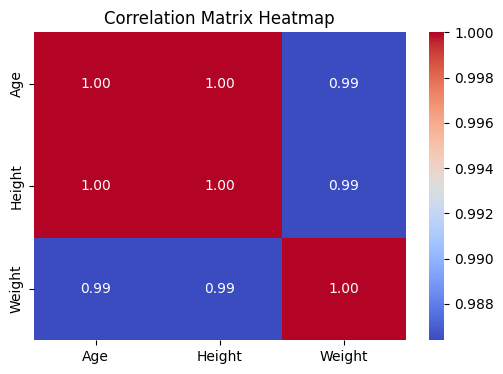

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt


# Generate heatmap
plt.figure(figsize=(6,4))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()


In [3]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation and p-value
r, p_value = pearsonr(df['Age'], df['Weight'])
print(f"Pearson correlation: {r}, p-value: {p_value}")

# Spearman correlation
r_s, p_s = spearmanr(df['Age'], df['Weight'])
print(f"Spearman correlation: {r_s}, p-value: {p_s}")

Pearson correlation: 0.9863939238321437, p-value: 0.0019012746601963693
Spearman correlation: 0.9999999999999999, p-value: 1.4042654220543672e-24


In [4]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans


In [5]:
data = {
    'Age': [25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 100],
    'Height': [160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230],
    'Weight': [60, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135]
}
df = pd.DataFrame(data)


In [6]:
df

,Age,Height,Weight
0,25,160,60
1,30,165,70
2,35,170,75
3,40,175,80
4,45,180,85
5,50,185,90
6,55,190,95
7,60,195,100
8,65,200,105
9,70,205,110


In [7]:
#(A) One-tailed T-Test: Height vs. Weight
t_stat, p_value = stats.ttest_rel(df['Height'], df['Weight'])
one_tailed_p = p_value / 2  # Since it's one-tailed

print(f"One-tailed T-Test: t-statistic = {t_stat}, p-value = {one_tailed_p}")


One-tailed T-Test: t-statistic = 286.00000000000006, p-value = 4.501749892247961e-28


In [8]:
#(B) Two-tailed T-Test: Height vs. Weight
t_stat, p_value = stats.ttest_rel(df['Height'], df['Weight'])
print(f"Two-tailed T-Test: t-statistic = {t_stat}, p-value = {p_value}")


Two-tailed T-Test: t-statistic = 286.00000000000006, p-value = 9.003499784495921e-28


In [9]:
# (A) One-Way ANOVA (Age, Height, Weight)
f_stat, p_value = stats.f_oneway(df['Age'], df['Height'], df['Weight'])
print(f"One-Way ANOVA: F-statistic = {f_stat}, p-value = {p_value}")


One-Way ANOVA: F-statistic = 138.91416309012862, p-value = 3.054778105285844e-19


In [12]:
# (B) Two-Way ANOVA (Needs categorical grouping)
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Convert 'Age' into categories (Young, Middle, Old)
df['Age_Group'] = pd.cut(df['Age'], bins=3, labels=["Young", "Middle", "Old"])

# Convert 'Height' into categories (Short, Medium, Tall)
df['Height_Group'] = pd.cut(df['Height'], bins=3, labels=["Short", "Medium", "Tall"])

# Fit the Two-Way ANOVA Model
model = ols('Weight ~ C(Age_Group) + C(Height_Group)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("Two-Way ANOVA Results:\n", anova_table)

Two-Way ANOVA Results:
                      sum_sq    df         F    PR(>F)
C(Age_Group)     250.000000   2.0  2.016129  0.183807
C(Height_Group)  338.333333   2.0  2.728495  0.113338
Residual         620.000000  10.0       NaN       NaN


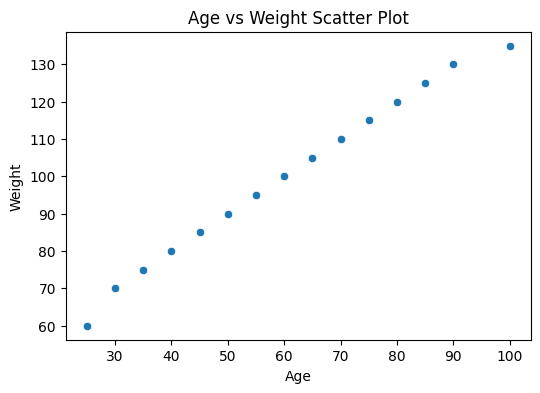

In [13]:
#(A) Scatter Plot: Age vs Weight
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Age'], y=df['Weight'])
plt.xlabel("Age")
plt.ylabel("Weight")
plt.title("Age vs Weight Scatter Plot")
plt.show()

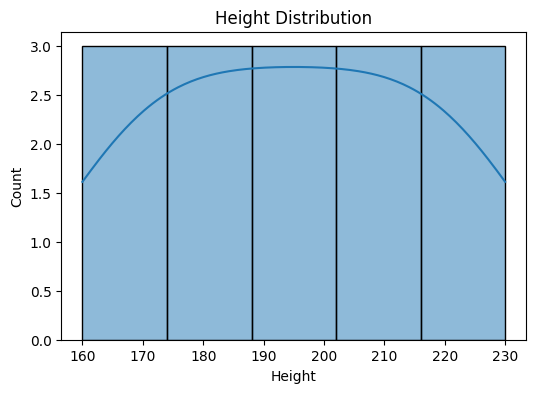

In [14]:
#(B) Histogram: Height Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Height'], bins=5, kde=True)
plt.xlabel("Height")
plt.title("Height Distribution")
plt.show()


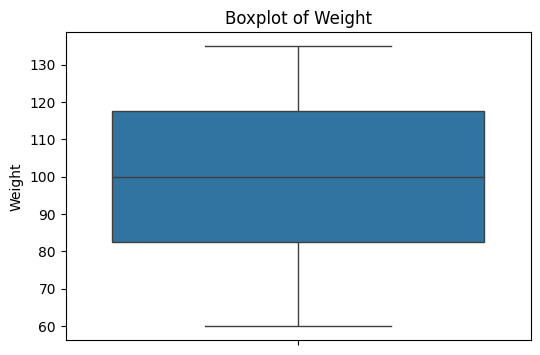

In [15]:
#(C) Box Plot: Weight Distribution
plt.figure(figsize=(6,4))
sns.boxplot(y=df['Weight'])
plt.ylabel("Weight")
plt.title("Boxplot of Weight")
plt.show()


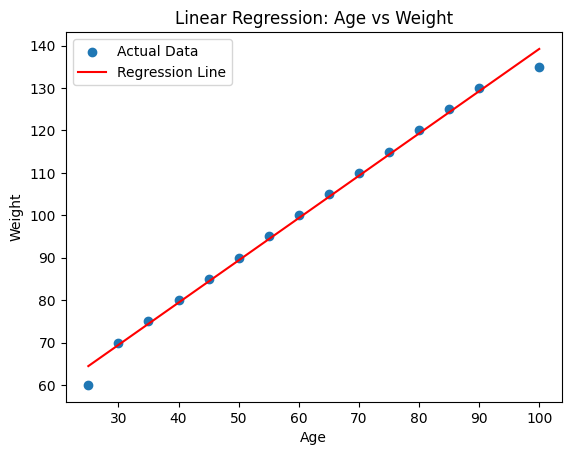

Regression Coefficients: [0.99706148], Intercept: 39.510623869801115


In [16]:
#(A) Linear Regression (Predict Weight from Age)
X = df[['Age']]
y = df['Weight']

model = LinearRegression()
model.fit(X, y)

predictions = model.predict(X)

plt.scatter(df['Age'], df['Weight'], label="Actual Data")
plt.plot(df['Age'], predictions, color='red', label="Regression Line")
plt.xlabel("Age")
plt.ylabel("Weight")
plt.title("Linear Regression: Age vs Weight")
plt.legend()
plt.show()

print(f"Regression Coefficients: {model.coef_}, Intercept: {model.intercept_}")


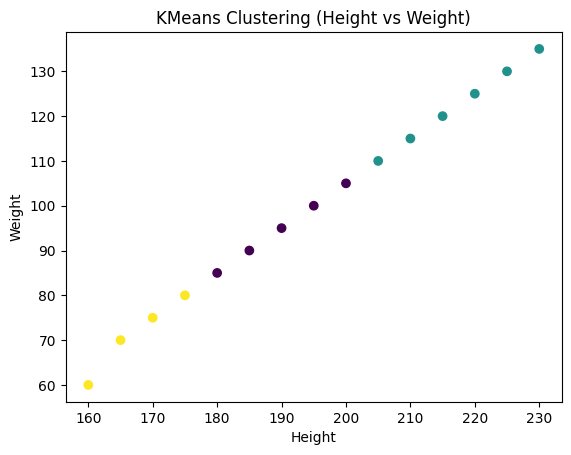

In [17]:
#(B) Clustering (KMeans: Height & Weight)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['Height', 'Weight']])

plt.scatter(df['Height'], df['Weight'], c=df['Cluster'], cmap='viridis')
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("KMeans Clustering (Height vs Weight)")
plt.show()
